# MACHINE LEARNING_ASSIGNMENT_2

# Topic : K-Means (OOP Implementation)

- Implemented as a reusable **`KMeansOOP` class** (fit / predict / plotting methods) instead of calling `sklearn.cluster.KMeans` directly.
- Uses **plain K-Means initialization** (centroids = `k` randomly chosen data points) instead of the **K-Means++** probability-weighted initialization.
- Records cluster assignments and centroid positions **at every iteration**, so we can visualize how the clusters evolve — mirroring the reference "ITERATIONS : 1 / 3 / 5 / 10" grid plot and the final single clustering plot.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, make_blobs
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
%matplotlib inline

## 2. `KMeansOOP` class

A from-scratch, object-oriented implementation of **Lloyd's algorithm** (standard K-Means).

**Key methods**

| Method | Purpose |
|---|---|
| `_init_centroids` | Randomly samples `k` data points as the starting centroids (plain K-Means, *not* K-Means++) |
| `_assign_clusters` | Assigns every point to its nearest centroid (Euclidean distance) |
| `_update_centroids` | Recomputes each centroid as the mean of its assigned points |
| `fit` | Runs the assign/update loop for `max_iter` iterations (or until convergence), saving a snapshot of centroids + labels after every iteration |
| `predict` | Assigns new/existing points to the fitted centroids |
| `plot_iterations` | Reproduces the reference "ITERATIONS : 1 / 3 / 5 / 10" 2×2 grid |
| `plot_final` | Reproduces the reference single final-clustering scatter plot |

In [2]:
class KMeansOOP:
    """
    Object-oriented implementation of plain K-Means clustering.

    Unlike K-Means++, this class initializes centroids by uniformly
    sampling k data points at random -- it does NOT use the
    probability-weighted-by-distance seeding scheme.

    Parameters
    ----------
    n_clusters : int
        Number of clusters (k).
    max_iter : int
        Maximum number of Lloyd's-algorithm iterations to run.
    random_state : int
        Seed controlling centroid initialization (reproducibility).
    tol : float
        Convergence tolerance: if the centroids move less than this
        (in Euclidean norm) between iterations, training stops early.
    """

    def __init__(self, n_clusters=4, max_iter=10, random_state=42, tol=1e-4):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.tol = tol

        # learned attributes (populated by .fit)
        self.centroids = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = 0
        self.history = []   # [(iteration, centroids_snapshot, labels_snapshot), ...]

    # ------------------------------------------------------------------
    # Initialization (plain K-Means, NOT K-Means++)
    # ------------------------------------------------------------------
    def _init_centroids(self, X):
        """Randomly select k data points from X to serve as initial centroids."""
        rng = np.random.RandomState(self.random_state)
        random_idx = rng.choice(X.shape[0], size=self.n_clusters, replace=False)
        return X[random_idx].copy()

    # ------------------------------------------------------------------
    # Assignment step
    # ------------------------------------------------------------------
    def _assign_clusters(self, X, centroids):
        """Return, for every row in X, the index of its nearest centroid."""
        distances = np.linalg.norm(
            X[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2
        )
        return np.argmin(distances, axis=1)

    # ------------------------------------------------------------------
    # Update step
    # ------------------------------------------------------------------
    def _update_centroids(self, X, labels):
        """Recompute each centroid as the mean of the points assigned to it."""
        new_centroids = np.zeros((self.n_clusters, X.shape[1]))
        rng = np.random.RandomState(self.random_state)
        for k in range(self.n_clusters):
            points_in_cluster = X[labels == k]
            if len(points_in_cluster) > 0:
                new_centroids[k] = points_in_cluster.mean(axis=0)
            else:
                # Empty cluster safeguard: re-seed with a random point
                new_centroids[k] = X[rng.randint(0, X.shape[0])]
        return new_centroids

    def _compute_inertia(self, X, centroids, labels):
        """Sum of squared distances of samples to their closest centroid."""
        return float(np.sum((X - centroids[labels]) ** 2))

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------
    def fit(self, X):
        """Run K-Means until convergence or max_iter, recording history."""
        X = np.asarray(X)
        self.centroids = self._init_centroids(X)
        self.history = []

        for iteration in range(1, self.max_iter + 1):
            labels = self._assign_clusters(X, self.centroids)
            new_centroids = self._update_centroids(X, labels)

            # snapshot AFTER this iteration's centroid update, for plotting
            self.history.append((iteration, new_centroids.copy(), labels.copy()))

            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            self.n_iter_ = iteration

            if shift < self.tol:
                break

        self.labels_ = self._assign_clusters(X, self.centroids)
        self.inertia_ = self._compute_inertia(X, self.centroids, self.labels_)
        return self

    def predict(self, X):
        """Assign each row of X to the nearest fitted centroid."""
        if self.centroids is None:
            raise RuntimeError("Model is not fitted yet. Call `fit` first.")
        return self._assign_clusters(np.asarray(X), self.centroids)

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

    # ------------------------------------------------------------------
    # Plotting
    # ------------------------------------------------------------------
    _PALETTE = ["#2ca878", "#e0389a", "#7b7ec8", "#d9720a", "#d94040", "#3f7fbf",
                "#8e44ad", "#16a085"]

    def _style_axis(self, ax):
        ax.set_facecolor("#d9d9d9")
        ax.grid(True, color="white", linewidth=1.2)
        ax.set_axisbelow(True)

    def plot_iterations(self, X, iterations=(1, 3, 5, 10), figsize=(9, 7)):
        """
        Plot a 2x2 grid showing cluster assignments + centroids at the
        requested checkpoint iterations (mirrors the reference
        'ITERATIONS : 1 / 3 / 5 / 10' figure). Only usable when X has
        2 features (2D data), since it is a 2D scatter plot.

        If the algorithm converged before a requested checkpoint, that
        panel falls back to the final recorded iteration.
        """
        if X.shape[1] != 2:
            raise ValueError("plot_iterations only supports 2D data (X.shape[1] == 2).")
        if not self.history:
            raise RuntimeError("Model is not fitted yet. Call `fit` first.")

        available_iters = [h[0] for h in self.history]
        last_iter = available_iters[-1]

        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.patch.set_facecolor("#d9d9d9")
        axes = axes.flatten()

        for ax, requested_iter in zip(axes, iterations):
            lookup_iter = requested_iter if requested_iter in available_iters else last_iter
            _, centroids_snap, labels_snap = next(
                h for h in self.history if h[0] == lookup_iter
            )

            self._style_axis(ax)
            for k in range(self.n_clusters):
                pts = X[labels_snap == k]
                ax.scatter(pts[:, 0], pts[:, 1], c=self._PALETTE[k % len(self._PALETTE)],
                           s=35, edgecolors="none")
            ax.scatter(centroids_snap[:, 0], centroids_snap[:, 1], c="black", s=160,
                       edgecolors="white", linewidths=1, zorder=5)

            suffix = "" if lookup_iter == requested_iter else " (converged)"
            ax.set_title(f"ITERATIONS : {requested_iter}{suffix}", fontsize=11, fontweight="bold")

        plt.tight_layout()
        plt.show()

    def plot_final(self, X, figsize=(7.5, 5), title=None):
        """
        Plot the final cluster assignments + centroids as a single
        scatter plot (mirrors the reference final-clustering figure).
        Only usable when X has 2 features.
        """
        if X.shape[1] != 2:
            raise ValueError("plot_final only supports 2D data (X.shape[1] == 2).")
        if self.labels_ is None:
            raise RuntimeError("Model is not fitted yet. Call `fit` first.")

        fig, ax = plt.subplots(figsize=figsize)
        fig.patch.set_facecolor("#d9d9d9")
        self._style_axis(ax)

        for k in range(self.n_clusters):
            pts = X[self.labels_ == k]
            ax.scatter(pts[:, 0], pts[:, 1], c=self._PALETTE[k % len(self._PALETTE)],
                       s=45, edgecolors="none")
        ax.scatter(self.centroids[:, 0], self.centroids[:, 1], c="black", s=220,
                   edgecolors="white", linewidths=1.2, zorder=5)

        if title:
            ax.set_title(title, fontsize=12, fontweight="bold")

        plt.tight_layout()
        plt.show()

    def __repr__(self):
        return (f"KMeansOOP(n_clusters={self.n_clusters}, max_iter={self.max_iter}, "
                f"random_state={self.random_state}, tol={self.tol})")

## 3. Part A — 2D visualization demo

The reference iteration/clustering plots are 2D scatter plots, so this section runs `KMeansOOP` on **synthetic 2D blob data** (`make_blobs`) purely so every iteration can be visualized directly in a scatter plot, the same way the reference images do it. Part B below applies the same class to the real (30-feature) breast-cancer dataset from the original notebook.

In [3]:
# Generate synthetic 2D data with 4 natural groupings
centers = [[-1.5, 4], [1, 4], [-1.5, 8], [1.5, 1]]
X_demo, _ = make_blobs(n_samples=90, centers=centers, n_features=2,
                        cluster_std=0.85, random_state=42)

X_demo[:5]

array([[ 2.19875114,  2.61227404],
       [ 0.67152058,  1.66902191],
       [-0.30762484,  6.8084266 ],
       [ 0.8132789 ,  4.30354569],
       [-1.41529634,  7.57204569]])

### 3.1 Fit `KMeansOOP` (plain K-Means, k=4)

In [4]:
kmeans_demo = KMeansOOP(n_clusters=4, max_iter=10, random_state=42)
kmeans_demo.fit(X_demo)

print(f"Converged after {kmeans_demo.n_iter_} iteration(s)")
print(f"Final inertia: {kmeans_demo.inertia_:.3f}")
print(f"Final centroids:\n{kmeans_demo.centroids}")
print(f"\nFirst 20 cluster assignments: {kmeans_demo.labels_[:20]}")

Converged after 5 iteration(s)
Final inertia: 99.218
Final centroids:
[[ 1.46448748  1.2708341 ]
 [-1.62185701  8.02857605]
 [-1.77436431  3.77618924]
 [ 0.92820689  4.2549244 ]]

First 20 cluster assignments: [0 0 1 3 1 0 0 0 2 2 0 3 2 3 3 1 0 0 2 0]


### 3.2 Cluster evolution across iterations

Reproduces the reference `ITERATIONS : 1 / 3 / 5 / 10` grid — colored points are cluster members, black dots are the centroids at that step.

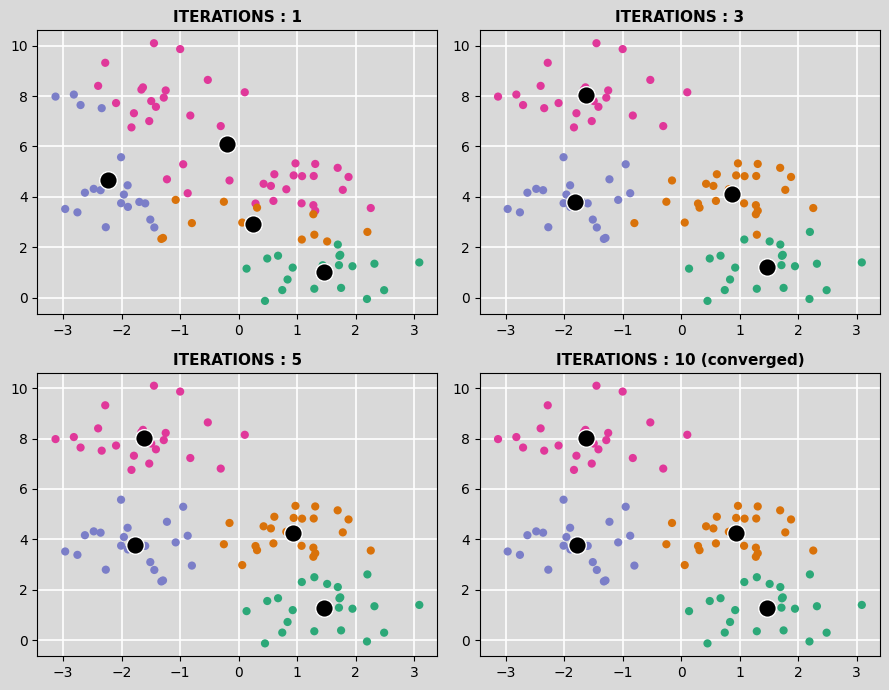

In [5]:
kmeans_demo.plot_iterations(X_demo, iterations=(1, 3, 5, 10))

### 3.3 Final clustering result

Reproduces the reference final single-plot clustering figure.

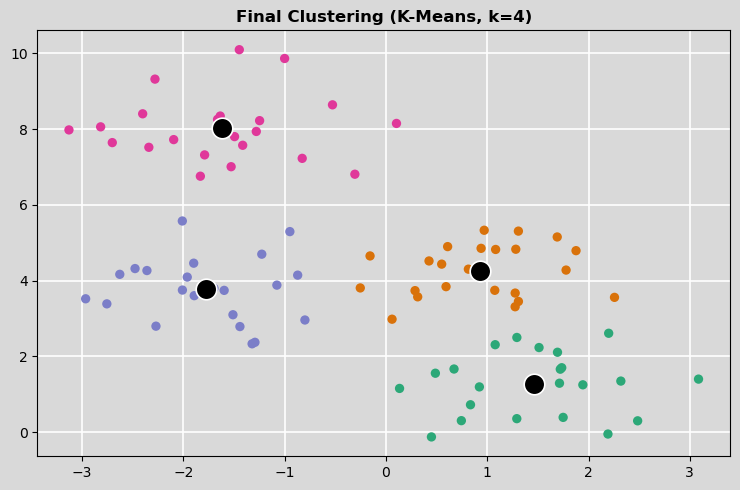

In [5]:
kmeans_demo.plot_final(X_demo, title="Final Clustering (K-Means, k=4)")

## 4. Part B — Breast cancer dataset (OOP counterpart of the original notebook)

This section reproduces the original notebook's workflow — load `load_breast_cancer`, standardize the features, and cluster into 3 groups — but using our `KMeansOOP` class with **plain K-Means initialization** instead of `sklearn.cluster.KMeans(init='k-means++')`.

### 4.1 Load dataset

In [6]:
# Load dataset
data = load_breast_cancer()

# Create DataFrame
df_cancer = pd.DataFrame(data.data)
df_cancer.columns = ['f' + str(i) for i in range(len(df_cancer.columns))]

# Add target column
df_cancer = df_cancer.assign(labels=data.target)

# Display first few rows
df_cancer.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f21,f22,f23,f24,f25,f26,f27,f28,f29,labels
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 4.2 Standardize features

In [7]:
# Select all columns except the last one
df_X = df_cancer.iloc[:, :-1]

# Standardize the features
std_X = StandardScaler().fit_transform(df_X)

# Convert back to DataFrame
df_X_std = pd.DataFrame(std_X, columns=df_X.columns)

df_X_std.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


### 4.3 Fit `KMeansOOP` (plain K-Means, k=3)

In [8]:
kmeans_cancer = KMeansOOP(n_clusters=3, max_iter=10, random_state=42)
kmeans_cancer.fit(std_X)

# Cluster assigned to each data point
cluster_per_pt = kmeans_cancer.labels_

# Display first 20 cluster assignments
display(cluster_per_pt[:20])

# Shape of cluster centers
display(kmeans_cancer.centroids.shape)

print(f"\nConverged after {kmeans_cancer.n_iter_} iteration(s), inertia = {kmeans_cancer.inertia_:.2f}")

array([1, 1, 1, 2, 1, 2, 1, 2, 2, 2, 0, 2, 1, 0, 2, 2, 0, 2, 1, 0])

(3, 30)


Converged after 9 iteration(s), inertia = 10061.80


### 4.4 Visualizing the high-dimensional clustering

`plot_iterations` / `plot_final` only work on 2D data (they're direct scatter plots). To visualize this 30-feature clustering the same way, we project the standardized features down to 2 principal components with PCA, then re-run `KMeansOOP` **in that 2D projected space** so the iteration snapshots are visually meaningful.

Converged after 10 iteration(s)


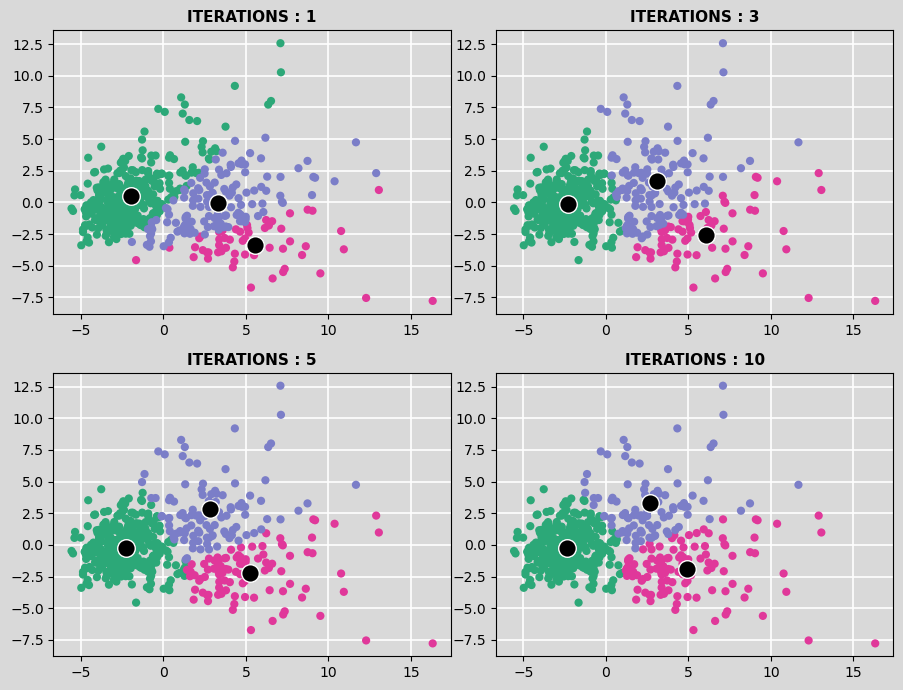

In [9]:
from sklearn.decomposition import PCA

X_pca = PCA(n_components=2, random_state=42).fit_transform(std_X)

kmeans_cancer_2d = KMeansOOP(n_clusters=3, max_iter=10, random_state=42)
kmeans_cancer_2d.fit(X_pca)

print(f"Converged after {kmeans_cancer_2d.n_iter_} iteration(s)")
kmeans_cancer_2d.plot_iterations(X_pca, iterations=(1, 3, 5, 10))

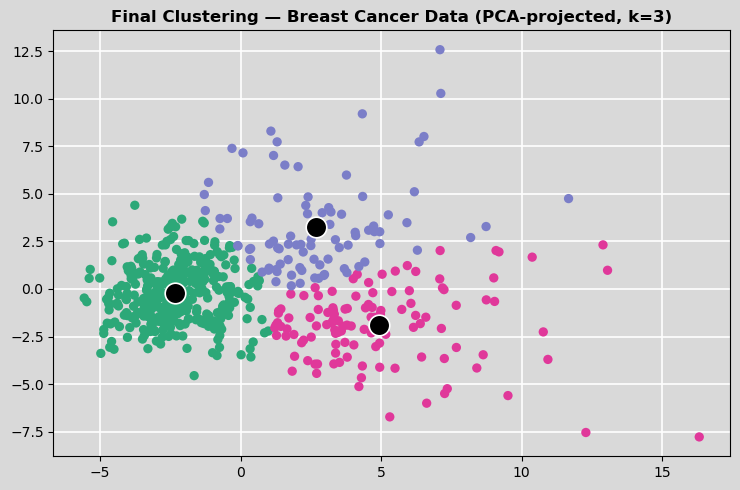

In [10]:
kmeans_cancer_2d.plot_final(X_pca, title="Final Clustering — Breast Cancer Data (PCA-projected, k=3)")

## 5. Summary

- `KMeansOOP` encapsulates the full plain K-Means algorithm (init → assign → update → repeat) as a reusable class with `fit` / `predict` / `fit_predict`, matching the familiar scikit-learn-style API.
- Initialization uses **uniform random sampling of k data points**, which is plain K-Means — **not** K-Means++'s distance-weighted seeding.
- Every iteration's centroids and labels are stored in `self.history`, enabling the `plot_iterations` grid (`ITERATIONS : 1 / 3 / 5 / 10`) and `plot_final` visualizations that mirror the reference figures.
- The same class is applied both to synthetic 2D data (Part A, directly plottable) and to the real 30-feature breast-cancer dataset (Part B, visualized via a 2D PCA projection).